# 24_noise_robustness_analysis_v5_with_exact_cnn_loader_fixed.ipynb

Аналитический ноутбук для проверки **robustness / noise sensitivity** текущих моделей на существующем датасете.

Модели:
- **CNN baseline**
- **DeepONet v2**
- **FNO v1**
- **Safe Frozen Hybrid**

Типы возмущений:
1. **Additive Gaussian noise**
2. **Receiver dropout**
3. **Phase jitter**

На выходе:
- таблицы средних метрик по уровням шума;
- degradation curves;
- сравнение относительного ухудшения по моделям;
- несколько визуальных примеров на одном и том же sample при чистом и шумном входе.


## 0. Важно
`M_hom` считается через `j-Wave`, поэтому JAX запускается на **CPU**.

Все модели используются только в режиме **inference**.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",

    "cnn_ckpt": "/workspace/reference_points/baseline_residual_v2_main/baseline_model.pt",

    "deeponet_ckpt": "/workspace/reference_points/deeponet_v2_main/deeponet_best.pt",
    "fno_ckpt": "/workspace/reference_points/fno_v1/fno_best.pt",
    "safe_hybrid_ckpt": "/workspace/reference_points/safe_hybrid_frozen_deeponet_refiner_v1/safe_hybrid_best.pt",

    "run_name": "noise_robustness_analysis_v5_with_exact_cnn_loader_fixed",

    "enable_cnn": True,

    "mask_half_width": 2,
    "use_residual": True,

    "max_test_samples": None,
    "num_repeats": 3,

    "gaussian_sigmas": [0.0, 0.01, 0.02, 0.05, 0.10],
    "receiver_dropout_fracs": [0.0, 0.05, 0.10, 0.20, 0.30],
    "phase_jitter_stds": [0.0, 0.05, 0.10, 0.20, 0.30],

    "vis_example_index": 0,
}
CFG


{'dataset_root': '/workspace/usct_dataset_v2',
 'cnn_ckpt': '/workspace/reference_points/baseline_residual_v2_main/baseline_model.pt',
 'deeponet_ckpt': '/workspace/reference_points/deeponet_v2_main/deeponet_best.pt',
 'fno_ckpt': '/workspace/reference_points/fno_v1/fno_best.pt',
 'safe_hybrid_ckpt': '/workspace/reference_points/safe_hybrid_frozen_deeponet_refiner_v1/safe_hybrid_best.pt',
 'run_name': 'noise_robustness_analysis_v5_with_exact_cnn_loader_fixed',
 'enable_cnn': True,
 'mask_half_width': 2,
 'use_residual': True,
 'max_test_samples': None,
 'num_repeats': 3,
 'gaussian_sigmas': [0.0, 0.01, 0.02, 0.05, 0.1],
 'receiver_dropout_fracs': [0.0, 0.05, 0.1, 0.2, 0.3],
 'phase_jitter_stds': [0.0, 0.05, 0.1, 0.2, 0.3],
 'vis_example_index': 0}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TEST_DIR = OUT_ROOT / "test"
CNN_CKPT_PATH = Path(CFG["cnn_ckpt"])
DEEPO_CKPT_PATH = Path(CFG["deeponet_ckpt"])
FNO_CKPT_PATH = Path(CFG["fno_ckpt"])
SAFE_CKPT_PATH = Path(CFG["safe_hybrid_ckpt"])

assert TEST_DIR.exists(), TEST_DIR
if CFG.get("enable_cnn", True):
    print("CNN checkpoint exists:", CNN_CKPT_PATH.exists(), "|", CNN_CKPT_PATH)
assert DEEPO_CKPT_PATH.exists(), DEEPO_CKPT_PATH
assert FNO_CKPT_PATH.exists(), FNO_CKPT_PATH
assert SAFE_CKPT_PATH.exists(), SAFE_CKPT_PATH

test_files = sorted(TEST_DIR.glob("*.npz"))
if CFG["max_test_samples"] is not None:
    test_files = test_files[:int(CFG["max_test_samples"])]

print("test samples used:", len(test_files))


CNN checkpoint exists: True | /workspace/reference_points/baseline_residual_v2_main/baseline_model.pt
test samples used: 800


In [5]:
sample0 = np.load(test_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

train_dir = OUT_ROOT / "train"
all_c_values = []
for p in sorted(train_dir.glob("*.npz")):
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}

print("S, R:", S, R)
print("H, W:", H, W)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` через j-Wave

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_2584/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 7.234201192855835 sec


## 2. Dataset

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTNoiseDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [10]:
ds_test = USCTNoiseDataset(
    test_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, meta0 = ds_test[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print(meta0)

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32 -0.7432032227516174 0.5520349740982056
{'path': '/workspace/usct_dataset_v2/test/sample_00000.npz', 'x_scale': 5060.05078125}


## 3. Model definitions and loading

### Optional CNN baseline

Ниже добавлена **baseline CNN** как опциональная модель для тех же robustness-тестов.
Если чекпоинт по пути `CFG['cnn_ckpt']` существует и архитектура совпадает, CNN будет оценена вместе с остальными моделями.
Если нет — ноутбук просто пропустит CNN и продолжит работу.

Здесь уже подставлена точная CNN-архитектура `SimpleUSCTBaseline` из `05_baseline_train_v2.ipynb`.


In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class SimpleUSCTBaseline(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, 32, stride=1)
        self.enc2 = ConvBlock(32, 64, stride=2)
        self.enc3 = ConvBlock(64, 128, stride=2)
        self.enc4 = ConvBlock(128, 128, stride=2)

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 2 * 32, 128 * 12 * 12),
            nn.GELU(),
        )

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.enc1(x)
        z = self.enc2(z)
        z = self.enc3(z)
        z = self.enc4(z)
        z = self.flatten(z)
        z = self.fc(z)
        z = z.view(x.shape[0], 128, 12, 12)
        return self.dec(z)


In [12]:
class BranchEncoderV2(nn.Module):
    def __init__(self, out_dim=192, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 192),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(192 * 2 * 32, 384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, out_dim),
        )

    def forward(self, x):
        return self.net(x)

    def forward_with_features(self, x):
        feat = self.net[:12](x)
        vec = self.net[12:](feat)
        return vec, feat

class TrunkNetV2(nn.Module):
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)

        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords

        y = coords[:, 0:1]
        x = coords[:, 1:2]
        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]

        feats = [coords, torch.sin(y_proj), torch.cos(y_proj), torch.sin(x_proj), torch.cos(x_proj)]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))

class DeepONet2DV2(nn.Module):
    def __init__(self, branch_width=192, trunk_width=192, trunk_hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.width = int(branch_width)
        self.branch = BranchEncoderV2(out_dim=branch_width, dropout=dropout)
        self.trunk = TrunkNetV2(width=trunk_width, hidden=trunk_hidden, num_fourier_features=num_fourier_features, dropout=dropout)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x, coords):
        b = self.branch(x)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        return out.view(x.shape[0], 1, H, W)

In [13]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        scale = 1 / (in_channels * out_channels)
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        x = x.float()
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(
            batchsize, self.out_channels, x.size(-2), x.size(-1)//2 + 1,
            dtype=torch.cfloat, device=x.device
        )
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)

    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))

class FNO2dBaseline(nn.Module):
    def __init__(self, width=48, depth=4, modes1=24, modes2=24, padding=8):
        super().__init__()
        self.padding = padding
        self.input_proj = nn.Conv2d(4, width, kernel_size=1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def get_grid(self, batch_size, device):
        yy = torch.linspace(-1.0, 1.0, H, device=device)
        xx = torch.linspace(-1.0, 1.0, W, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        x = F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)

        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])

        for block in self.blocks:
            x = block(x)

        if self.padding > 0:
            x = x[..., :H, :W]

        return self.head(x)

In [14]:
class SmallResidualRefiner(nn.Module):
    def __init__(self, feat_in=192, feat_decode=32):
        super().__init__()
        self.feat_decoder = nn.Sequential(
            nn.Conv2d(feat_in, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, feat_decode, kernel_size=3, padding=1),
            nn.GELU(),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(1 + feat_decode, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
        )

    def forward(self, coarse, feat_map):
        h = self.feat_decoder(feat_map)
        h = torch.nn.functional.interpolate(h, size=coarse.shape[-2:], mode="bilinear", align_corners=False)
        z = torch.cat([coarse, h], dim=1)
        return self.refine(z)

class SafeFrozenHybrid(nn.Module):
    def __init__(self, backbone, feat_decode=32, max_refine_alpha=0.20, init_refine_alpha=0.03):
        super().__init__()
        self.backbone = backbone
        self.refiner = SmallResidualRefiner(feat_in=192, feat_decode=feat_decode)
        self.max_refine_alpha = float(max_refine_alpha)

        init_ratio = np.clip(init_refine_alpha / max_refine_alpha, 1e-4, 1 - 1e-4)
        init_raw = math.log(init_ratio / (1.0 - init_ratio))
        self.raw_alpha = nn.Parameter(torch.tensor(init_raw, dtype=torch.float32))

    def alpha(self):
        return self.max_refine_alpha * torch.sigmoid(self.raw_alpha)

    def forward(self, x, coords):
        with torch.no_grad():
            branch_vec, feat_map = self.backbone.branch.forward_with_features(x)
            trunk_vec = self.backbone.trunk(coords)
            coarse = torch.matmul(branch_vec, trunk_vec.t()) / math.sqrt(self.backbone.width) + self.backbone.bias
            coarse = coarse.view(x.shape[0], 1, H, W)

        residual = self.refiner(coarse, feat_map)
        return coarse + self.alpha() * residual

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_ckpt = torch.load(CNN_CKPT_PATH, map_location=device) if (CFG.get("enable_cnn", True) and CNN_CKPT_PATH.exists()) else None
deepo_ckpt = torch.load(DEEPO_CKPT_PATH, map_location=device)
fno_ckpt = torch.load(FNO_CKPT_PATH, map_location=device)
safe_ckpt = torch.load(SAFE_CKPT_PATH, map_location=device)

deepo_cfg = deepo_ckpt["config"]
fno_cfg = fno_ckpt["config"]
safe_cfg = safe_ckpt["config"]

yy = np.linspace(-1.0, 1.0, H, dtype=np.float32)
xx = np.linspace(-1.0, 1.0, W, dtype=np.float32)
grid_y, grid_x = np.meshgrid(yy, xx, indexing="ij")
coords = np.stack([grid_y, grid_x], axis=-1).reshape(-1, 2)
coords_t = torch.from_numpy(coords).to(device)

deepo = DeepONet2DV2(
    branch_width=deepo_cfg["branch_width"],
    trunk_width=deepo_cfg["trunk_width"],
    trunk_hidden=deepo_cfg["trunk_hidden"],
    num_fourier_features=deepo_cfg["num_fourier_features"],
    dropout=deepo_cfg["dropout"],
).to(device)
deepo.load_state_dict(deepo_ckpt["model_state_dict"], strict=True)
deepo.eval()

fno = FNO2dBaseline(
    width=fno_cfg["fno_width"],
    depth=fno_cfg["fno_depth"],
    modes1=fno_cfg["fno_modes_h"],
    modes2=fno_cfg["fno_modes_w"],
    padding=fno_cfg["fno_padding"],
).to(device)
fno.load_state_dict(fno_ckpt["model_state_dict"], strict=True)
fno.eval()

deepo_backbone = DeepONet2DV2(
    branch_width=safe_cfg["branch_width"],
    trunk_width=safe_cfg["trunk_width"],
    trunk_hidden=safe_cfg["trunk_hidden"],
    num_fourier_features=safe_cfg["num_fourier_features"],
    dropout=safe_cfg["dropout"],
).to(device)
deepo_backbone.load_state_dict(deepo_ckpt["model_state_dict"], strict=True)
deepo_backbone.eval()
for p in deepo_backbone.parameters():
    p.requires_grad = False

safe_hybrid = SafeFrozenHybrid(
    backbone=deepo_backbone,
    feat_decode=safe_cfg["feat_decode_channels"],
    max_refine_alpha=safe_cfg["max_refine_alpha"],
    init_refine_alpha=safe_cfg["init_refine_alpha"],
).to(device)
safe_hybrid.load_state_dict(safe_ckpt["model_state_dict"], strict=True)
safe_hybrid.eval()

models = {
    "DeepONet_v2": deepo,
    "FNO_v1": fno,
    "Safe_Hybrid": safe_hybrid,
}

def try_load_cnn_from_checkpoint(cnn_ckpt_obj):
    if cnn_ckpt_obj is None:
        print("CNN baseline skipped: checkpoint not found or enable_cnn=False")
        return None

    # Case 1: whole nn.Module was saved directly
    if isinstance(cnn_ckpt_obj, nn.Module):
        cnn_model = cnn_ckpt_obj.to(device)
        cnn_model.eval()
        print("CNN baseline loaded as full nn.Module object.")
        return cnn_model

    # Case 2: model stored under a field
    if isinstance(cnn_ckpt_obj, dict):
        if "model" in cnn_ckpt_obj and isinstance(cnn_ckpt_obj["model"], nn.Module):
            cnn_model = cnn_ckpt_obj["model"].to(device)
            cnn_model.eval()
            print("CNN baseline loaded from checkpoint['model'].")
            return cnn_model

    # Case 3: state_dict-like checkpoint
    state = cnn_ckpt_obj.get("model_state_dict", cnn_ckpt_obj) if isinstance(cnn_ckpt_obj, dict) else cnn_ckpt_obj
    if not isinstance(state, dict):
        print("CNN checkpoint format is not recognized:", type(cnn_ckpt_obj))
        return None

    print("CNN checkpoint top-level keys:", list(cnn_ckpt_obj.keys())[:20] if isinstance(cnn_ckpt_obj, dict) else "<not dict>")
    print("CNN state_dict first keys:", list(state.keys())[:20])

    # Try fallback architecture from notebook
    try:
        cnn_model = SimpleUSCTBaseline().to(device)
        missing, unexpected = cnn_model.load_state_dict(state, strict=False)
        if len(state) > 0 and len(missing) < len(state):
            cnn_model.eval()
            print("CNN baseline loaded with BaselineCNN(strict=False).")
            print("Missing keys:", missing[:20], "| count =", len(missing))
            print("Unexpected keys:", unexpected[:20], "| count =", len(unexpected))
            return cnn_model
        else:
            print("BaselineCNN does not match checkpoint structure.")
            print("Missing keys:", missing[:20], "| count =", len(missing))
            print("Unexpected keys:", unexpected[:20], "| count =", len(unexpected))
            return None
    except Exception as e:
        print("CNN loading attempt with SimpleUSCTBaseline failed.")
        print("Load error:", repr(e))
        return None

cnn_model = try_load_cnn_from_checkpoint(cnn_ckpt)
if cnn_model is not None:
    models["CNN_Baseline"] = cnn_model

print("Loaded models:", list(models.keys()))


CNN checkpoint top-level keys: ['model_state_dict', 'stats', 'best_epoch', 'best_val', 'experiment_config']
CNN state_dict first keys: ['enc1.block.0.weight', 'enc1.block.0.bias', 'enc1.block.1.weight', 'enc1.block.1.bias', 'enc1.block.3.weight', 'enc1.block.3.bias', 'enc1.block.4.weight', 'enc1.block.4.bias', 'enc2.block.0.weight', 'enc2.block.0.bias', 'enc2.block.1.weight', 'enc2.block.1.bias', 'enc2.block.3.weight', 'enc2.block.3.bias', 'enc2.block.4.weight', 'enc2.block.4.bias', 'enc3.block.0.weight', 'enc3.block.0.bias', 'enc3.block.1.weight', 'enc3.block.1.bias']
CNN baseline loaded with BaselineCNN(strict=False).
Missing keys: [] | count = 0
Unexpected keys: [] | count = 0
Loaded models: ['DeepONet_v2', 'FNO_v1', 'Safe_Hybrid', 'CNN_Baseline']


## 4. Perturbations

In [16]:
def perturb_gaussian(x_np, sigma, rng):
    if sigma <= 0:
        return x_np.copy()
    noise = rng.normal(0.0, sigma, size=x_np.shape).astype(np.float32)
    return x_np + noise

def perturb_receiver_dropout(x_np, frac, rng):
    if frac <= 0:
        return x_np.copy()
    x = x_np.copy()
    num_drop = int(round(R * frac))
    if num_drop <= 0:
        return x
    drop_idx = rng.choice(R, size=num_drop, replace=False)
    x[:, :, drop_idx] = 0.0
    return x

def perturb_phase_jitter(x_np, phase_std, rng):
    if phase_std <= 0:
        return x_np.copy()
    comp = x_np[0] + 1j * x_np[1]
    jitter = rng.normal(0.0, phase_std, size=comp.shape).astype(np.float32)
    comp_noisy = comp * np.exp(1j * jitter)
    return np.stack([comp_noisy.real, comp_noisy.imag], axis=0).astype(np.float32)

def apply_perturbation(x_np, perturbation_name, level, rng):
    if perturbation_name == "gaussian":
        return perturb_gaussian(x_np, level, rng)
    if perturbation_name == "receiver_dropout":
        return perturb_receiver_dropout(x_np, level, rng)
    if perturbation_name == "phase_jitter":
        return perturb_phase_jitter(x_np, level, rng)
    raise ValueError(perturbation_name)

## 5. Metrics and evaluation

In [17]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-8))

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

def compute_metrics(pred, target, data_range):
    return {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }

@torch.no_grad()
def predict_model(model_name, x_np):
    xb = torch.from_numpy(x_np).unsqueeze(0).to(device)

    if model_name == "DeepONet_v2":
        pred = models[model_name](xb, coords_t)[0, 0].cpu().numpy()
    elif model_name == "FNO_v1":
        pred = models[model_name](xb)[0, 0].cpu().numpy()
    elif model_name == "Safe_Hybrid":
        pred = models[model_name](xb, coords_t)[0, 0].cpu().numpy()
    elif model_name == "CNN_Baseline":
        pred = models[model_name](xb)[0, 0].cpu().numpy()
    else:
        raise ValueError(model_name)

    return np.clip(pred, -1.0, 1.0)

def evaluate_under_perturbation(dataset, perturbation_name, levels, num_repeats=3, seed=123):
    rows = []
    data_range = float(stats["c_max"] - stats["c_min"])

    for model_name in models.keys():
        print("=" * 80)
        print("Model:", model_name, "| perturbation:", perturbation_name)

        for level in levels:
            rep_metrics = []

            for rep in range(num_repeats):
                rng = np.random.default_rng(seed + rep + int(level * 10000) + abs(hash(model_name + perturbation_name)) % 1000)
                metrics_list = []

                for idx in range(len(dataset)):
                    x, c, meta = dataset[idx]
                    x_np = x.numpy()
                    x_noisy = apply_perturbation(x_np, perturbation_name, level, rng)

                    pred = predict_model(model_name, x_noisy)
                    target = c[0].numpy()

                    pred_phys = denorm_c_from_minus1_1(pred, stats["c_min"], stats["c_max"])
                    target_phys = denorm_c_from_minus1_1(target, stats["c_min"], stats["c_max"])

                    metrics_list.append(compute_metrics(pred_phys, target_phys, data_range))

                rep_df = pd.DataFrame(metrics_list)
                rep_metrics.append(rep_df.mean().to_dict())

            rep_df = pd.DataFrame(rep_metrics)
            row = {
                "model": model_name,
                "perturbation": perturbation_name,
                "level": float(level),
                "num_repeats": int(num_repeats),
                "mse_mean": float(rep_df["mse"].mean()),
                "mse_std_over_repeats": float(rep_df["mse"].std()),
                "rmse_mean": float(rep_df["rmse"].mean()),
                "rmse_std_over_repeats": float(rep_df["rmse"].std()),
                "relative_l2_mean": float(rep_df["relative_l2"].mean()),
                "relative_l2_std_over_repeats": float(rep_df["relative_l2"].std()),
                "psnr_mean": float(rep_df["psnr"].mean()),
                "psnr_std_over_repeats": float(rep_df["psnr"].std()),
            }
            rows.append(row)

            print(
                f"level={level:.4f} | "
                f"rmse={row['rmse_mean']:.4f} ± {row['rmse_std_over_repeats']:.4f} | "
                f"rel_l2={row['relative_l2_mean']:.6f} | "
                f"psnr={row['psnr_mean']:.3f}"
            )

    return pd.DataFrame(rows)


## 6. Run experiments

In [18]:
df_gaussian = evaluate_under_perturbation(ds_test, "gaussian", CFG["gaussian_sigmas"], CFG["num_repeats"], seed=111)
df_receiver_dropout = evaluate_under_perturbation(ds_test, "receiver_dropout", CFG["receiver_dropout_fracs"], CFG["num_repeats"], seed=222)
df_phase_jitter = evaluate_under_perturbation(ds_test, "phase_jitter", CFG["phase_jitter_stds"], CFG["num_repeats"], seed=333)

df_all = pd.concat([df_gaussian, df_receiver_dropout, df_phase_jitter], axis=0, ignore_index=True)
display(df_all.head())

Model: DeepONet_v2 | perturbation: gaussian
level=0.0000 | rmse=13.8302 ± 0.0000 | rel_l2=0.009269 | psnr=23.338
level=0.0100 | rmse=13.8344 ± 0.0003 | rel_l2=0.009272 | psnr=23.335
level=0.0200 | rmse=13.8453 ± 0.0004 | rel_l2=0.009279 | psnr=23.328
level=0.0500 | rmse=13.9314 ± 0.0032 | rel_l2=0.009337 | psnr=23.269
level=0.1000 | rmse=14.2409 ± 0.0033 | rel_l2=0.009545 | psnr=23.061
Model: FNO_v1 | perturbation: gaussian
level=0.0000 | rmse=17.3592 ± 0.0000 | rel_l2=0.011634 | psnr=21.347
level=0.0100 | rmse=17.3705 ± 0.0034 | rel_l2=0.011641 | psnr=21.341
level=0.0200 | rmse=17.4020 ± 0.0036 | rel_l2=0.011662 | psnr=21.323
level=0.0500 | rmse=17.6428 ± 0.0079 | rel_l2=0.011824 | psnr=21.189
level=0.1000 | rmse=18.6305 ± 0.0107 | rel_l2=0.012488 | psnr=20.662
Model: Safe_Hybrid | perturbation: gaussian
level=0.0000 | rmse=13.6106 ± 0.0000 | rel_l2=0.009122 | psnr=23.526
level=0.0100 | rmse=13.6158 ± 0.0010 | rel_l2=0.009125 | psnr=23.523
level=0.0200 | rmse=13.6295 ± 0.0013 | rel_l2

,model,perturbation,level,num_repeats,mse_mean,mse_std_over_repeats,rmse_mean,rmse_std_over_repeats,relative_l2_mean,relative_l2_std_over_repeats,psnr_mean,psnr_std_over_repeats
0,DeepONet_v2,gaussian,0.00,3,207.254257,0.000000,13.830151,2.175584e-15,0.009269,0.000000e+00,23.338234,0.000000
1,DeepONet_v2,gaussian,0.01,3,207.372863,0.004833,13.834356,2.538263e-04,0.009272,1.722799e-07,23.335369,0.000178
2,DeepONet_v2,gaussian,0.02,3,207.671824,0.017832,13.845331,4.184278e-04,0.009279,2.794952e-07,23.327750,0.000301
3,DeepONet_v2,gaussian,0.05,3,210.064060,0.102773,13.931412,3.192354e-03,0.009337,2.138457e-06,23.269009,0.001869
4,DeepONet_v2,gaussian,0.10,3,218.744551,0.106317,14.240912,3.261940e-03,0.009545,2.187344e-06,23.061113,0.001616


## 7. Plots

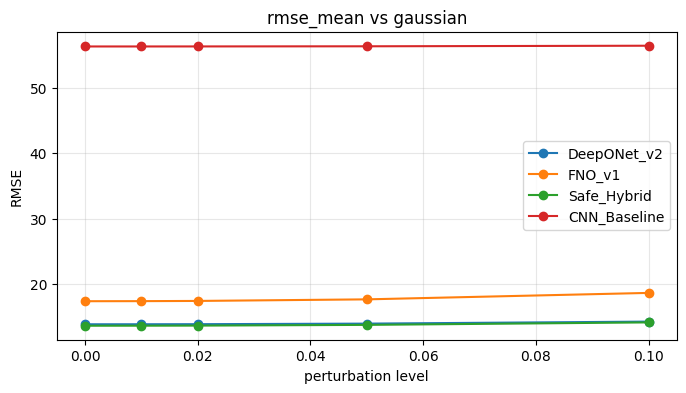

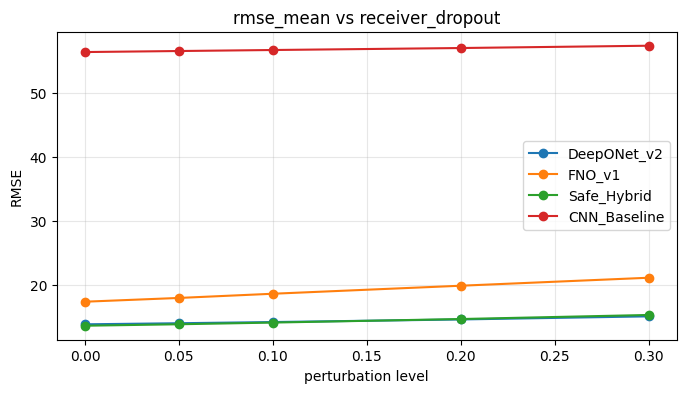

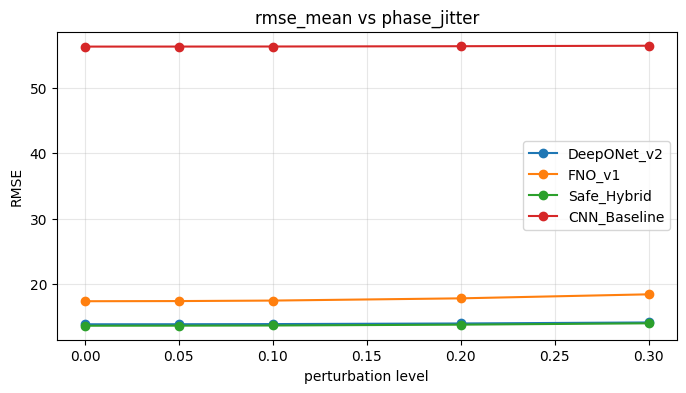

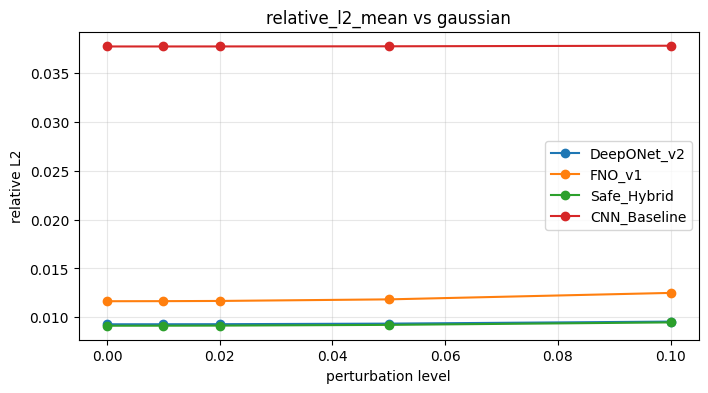

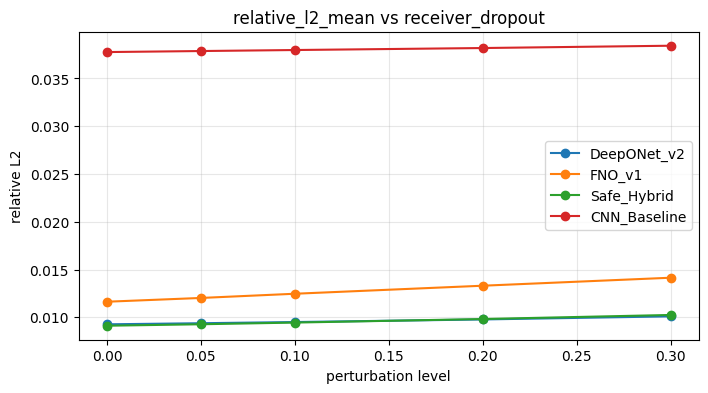

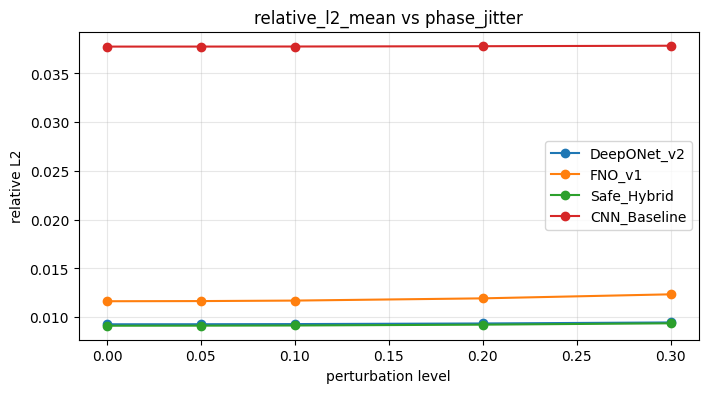

In [19]:
def plot_metric_curve(df, perturbation_name, metric="rmse_mean", ylabel=None):
    sub = df[df["perturbation"] == perturbation_name].copy()
    plt.figure(figsize=(8, 4))
    for model_name in sub["model"].unique():
        cur = sub[sub["model"] == model_name].sort_values("level")
        plt.plot(cur["level"], cur[metric], marker="o", label=model_name)
    plt.xlabel("perturbation level")
    plt.ylabel(ylabel or metric)
    plt.title(f"{metric} vs {perturbation_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_metric_curve(df_all, "gaussian", "rmse_mean", "RMSE")
plot_metric_curve(df_all, "receiver_dropout", "rmse_mean", "RMSE")
plot_metric_curve(df_all, "phase_jitter", "rmse_mean", "RMSE")

plot_metric_curve(df_all, "gaussian", "relative_l2_mean", "relative L2")
plot_metric_curve(df_all, "receiver_dropout", "relative_l2_mean", "relative L2")
plot_metric_curve(df_all, "phase_jitter", "relative_l2_mean", "relative L2")

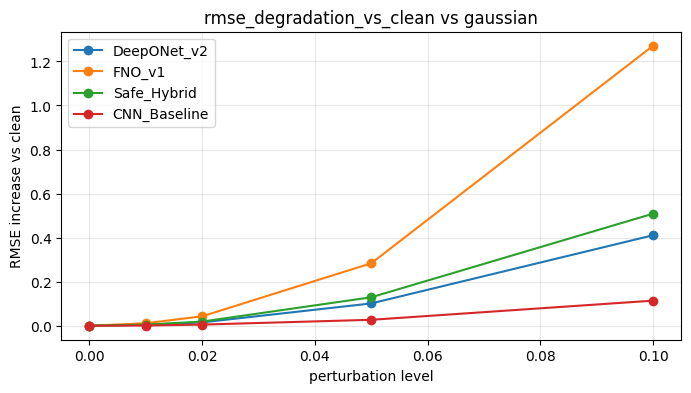

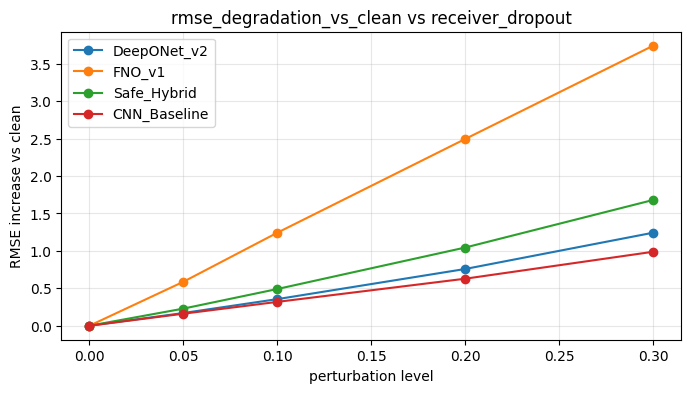

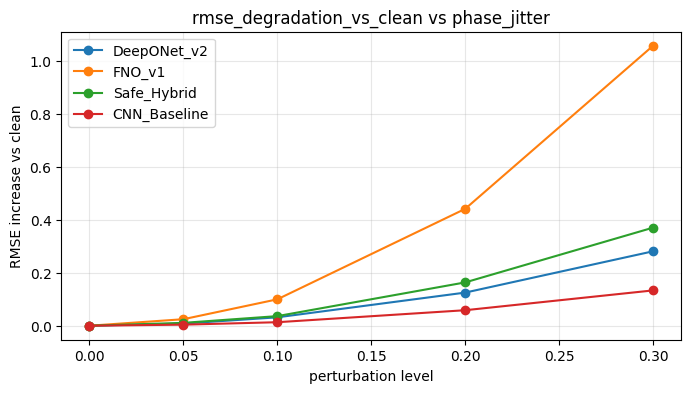

In [20]:
clean_rows = df_all[df_all["level"] == 0.0][["model", "perturbation", "rmse_mean"]].copy()
clean_ref = clean_rows.groupby("model")["rmse_mean"].mean().to_dict()

df_all["rmse_degradation_vs_clean"] = df_all.apply(lambda r: r["rmse_mean"] - clean_ref[r["model"]], axis=1)
df_all["rmse_ratio_vs_clean"] = df_all.apply(lambda r: r["rmse_mean"] / clean_ref[r["model"]], axis=1)

plot_metric_curve(df_all, "gaussian", "rmse_degradation_vs_clean", "RMSE increase vs clean")
plot_metric_curve(df_all, "receiver_dropout", "rmse_degradation_vs_clean", "RMSE increase vs clean")
plot_metric_curve(df_all, "phase_jitter", "rmse_degradation_vs_clean", "RMSE increase vs clean")

## 8. Compact tables

In [21]:
def compact_pivot(df, perturbation_name, value_col):
    sub = df[df["perturbation"] == perturbation_name].copy()
    return sub.pivot(index="level", columns="model", values=value_col)

print("Gaussian / RMSE")
display(compact_pivot(df_all, "gaussian", "rmse_mean"))

print("Receiver dropout / RMSE")
display(compact_pivot(df_all, "receiver_dropout", "rmse_mean"))

print("Phase jitter / RMSE")
display(compact_pivot(df_all, "phase_jitter", "rmse_mean"))

Gaussian / RMSE


model,CNN_Baseline,DeepONet_v2,FNO_v1,Safe_Hybrid
level,,,,
0.00,56.325530,13.830151,17.359155,13.610649
0.01,56.326409,13.834356,17.370484,13.615822
0.02,56.330705,13.845331,17.401979,13.629528
0.05,56.352388,13.931412,17.642774,13.739807
0.10,56.439371,14.240912,18.630511,14.119448


Receiver dropout / RMSE


model,CNN_Baseline,DeepONet_v2,FNO_v1,Safe_Hybrid
level,,,,
0.00,56.325530,13.830151,17.359155,13.610649
0.05,56.486215,13.999968,17.946474,13.839275
0.10,56.644128,14.185422,18.601742,14.101132
0.20,56.953640,14.588150,19.853783,14.655104
0.30,57.313442,15.072563,21.099601,15.290276


Phase jitter / RMSE


model,CNN_Baseline,DeepONet_v2,FNO_v1,Safe_Hybrid
level,,,,
0.00,56.325530,13.830151,17.359155,13.610649
0.05,56.329569,13.838162,17.383734,13.621451
0.10,56.338749,13.861881,17.458790,13.646863
0.20,56.384048,13.955153,17.800179,13.774111
0.30,56.458778,14.111012,18.415643,13.980726


## 9. Visual examples

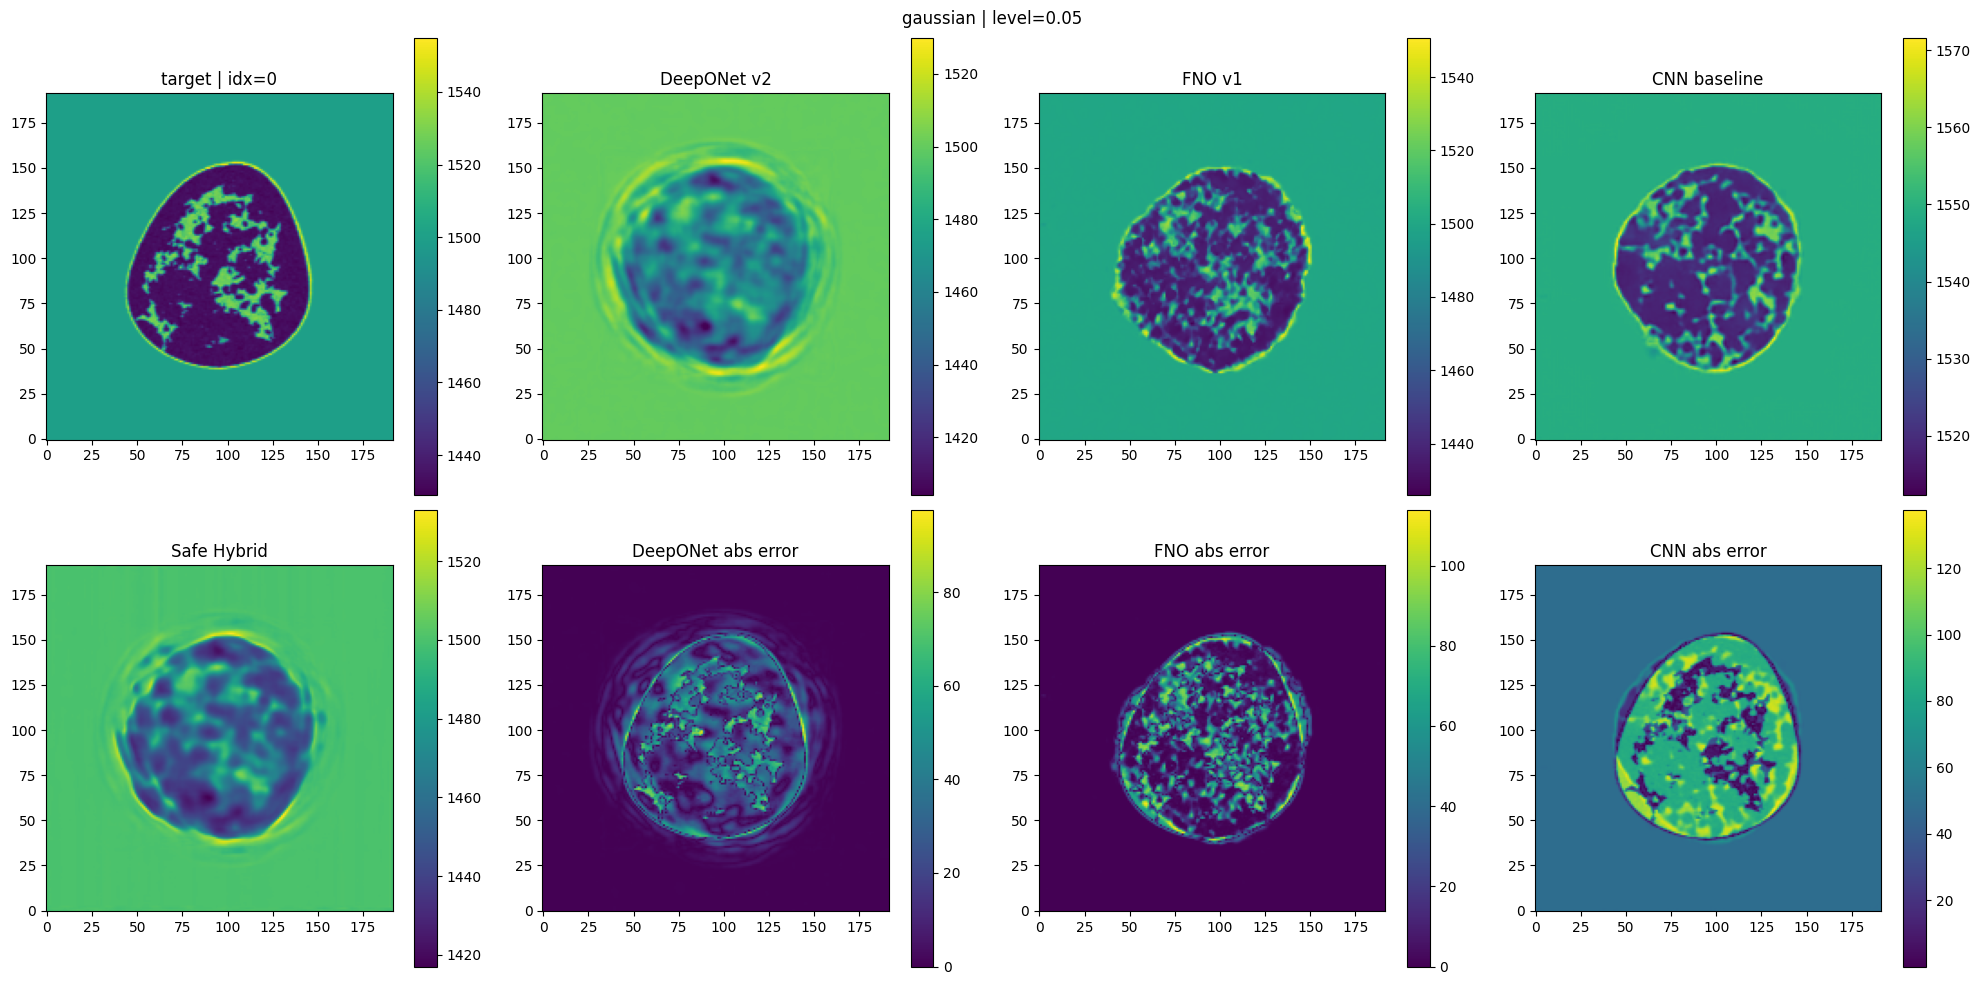

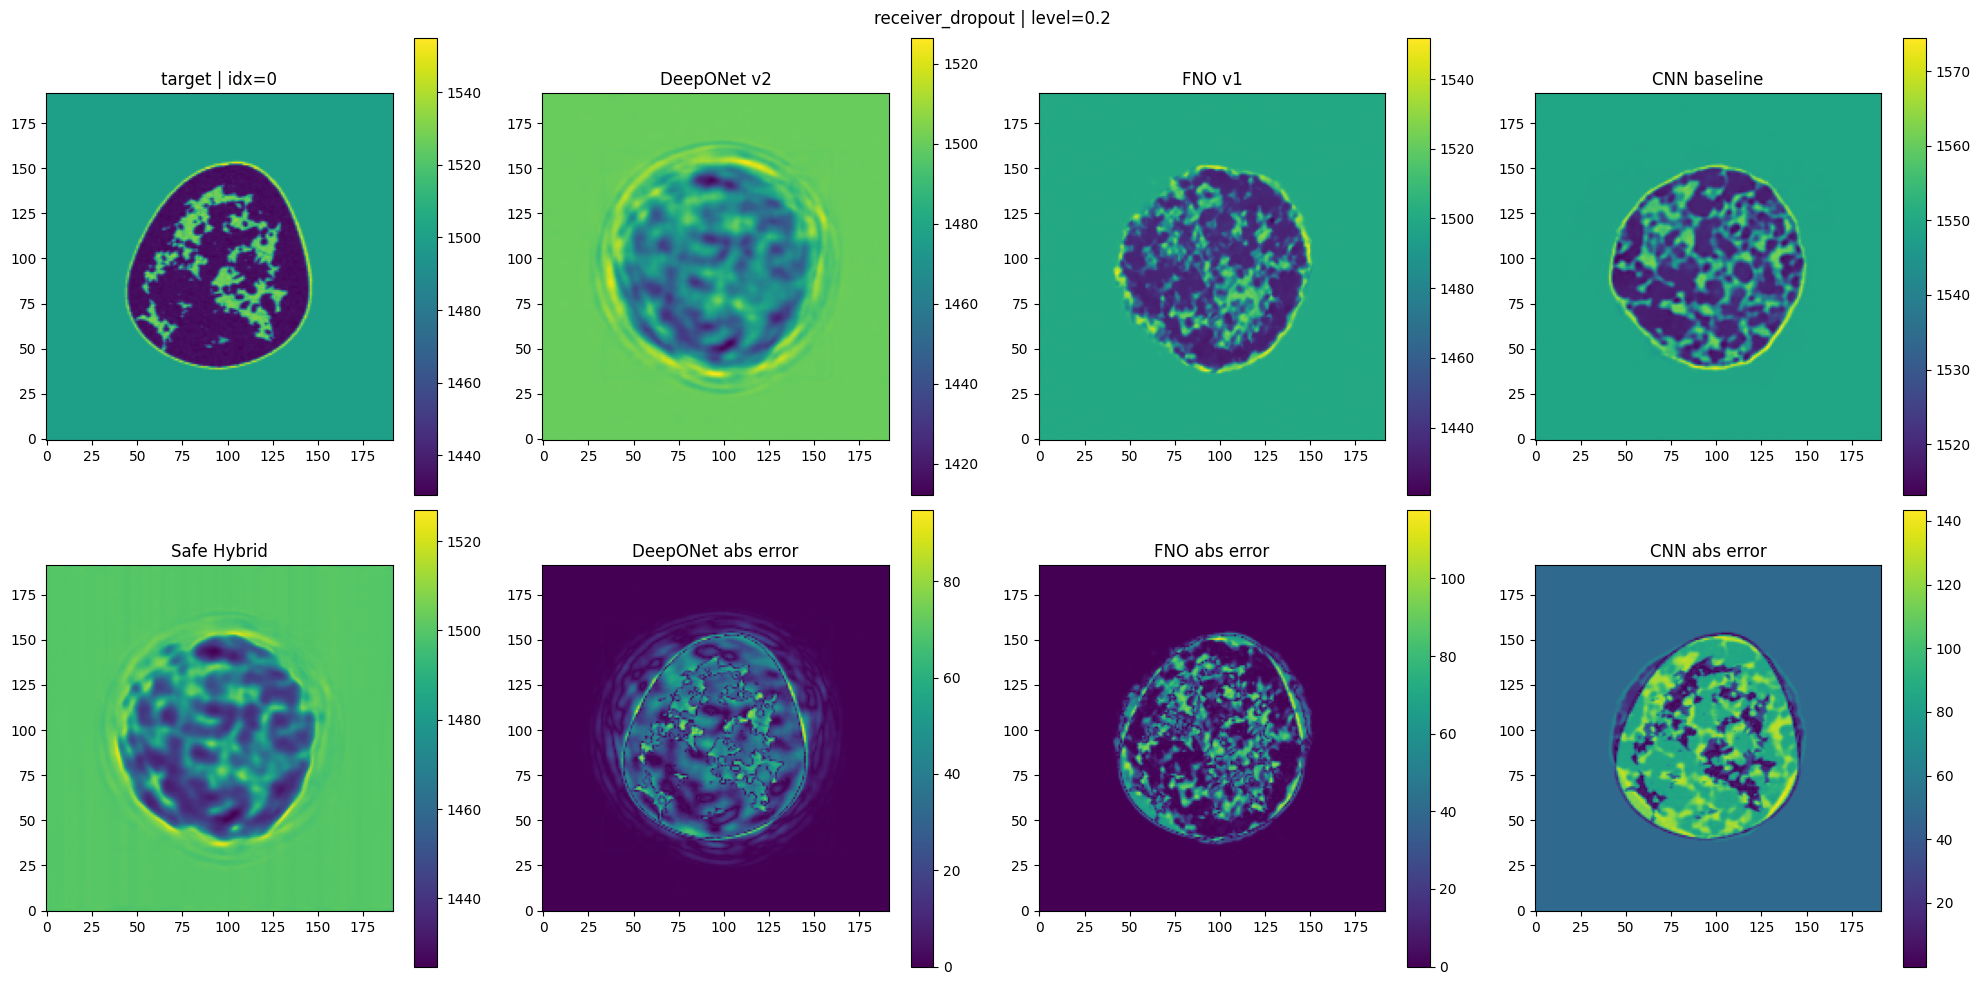

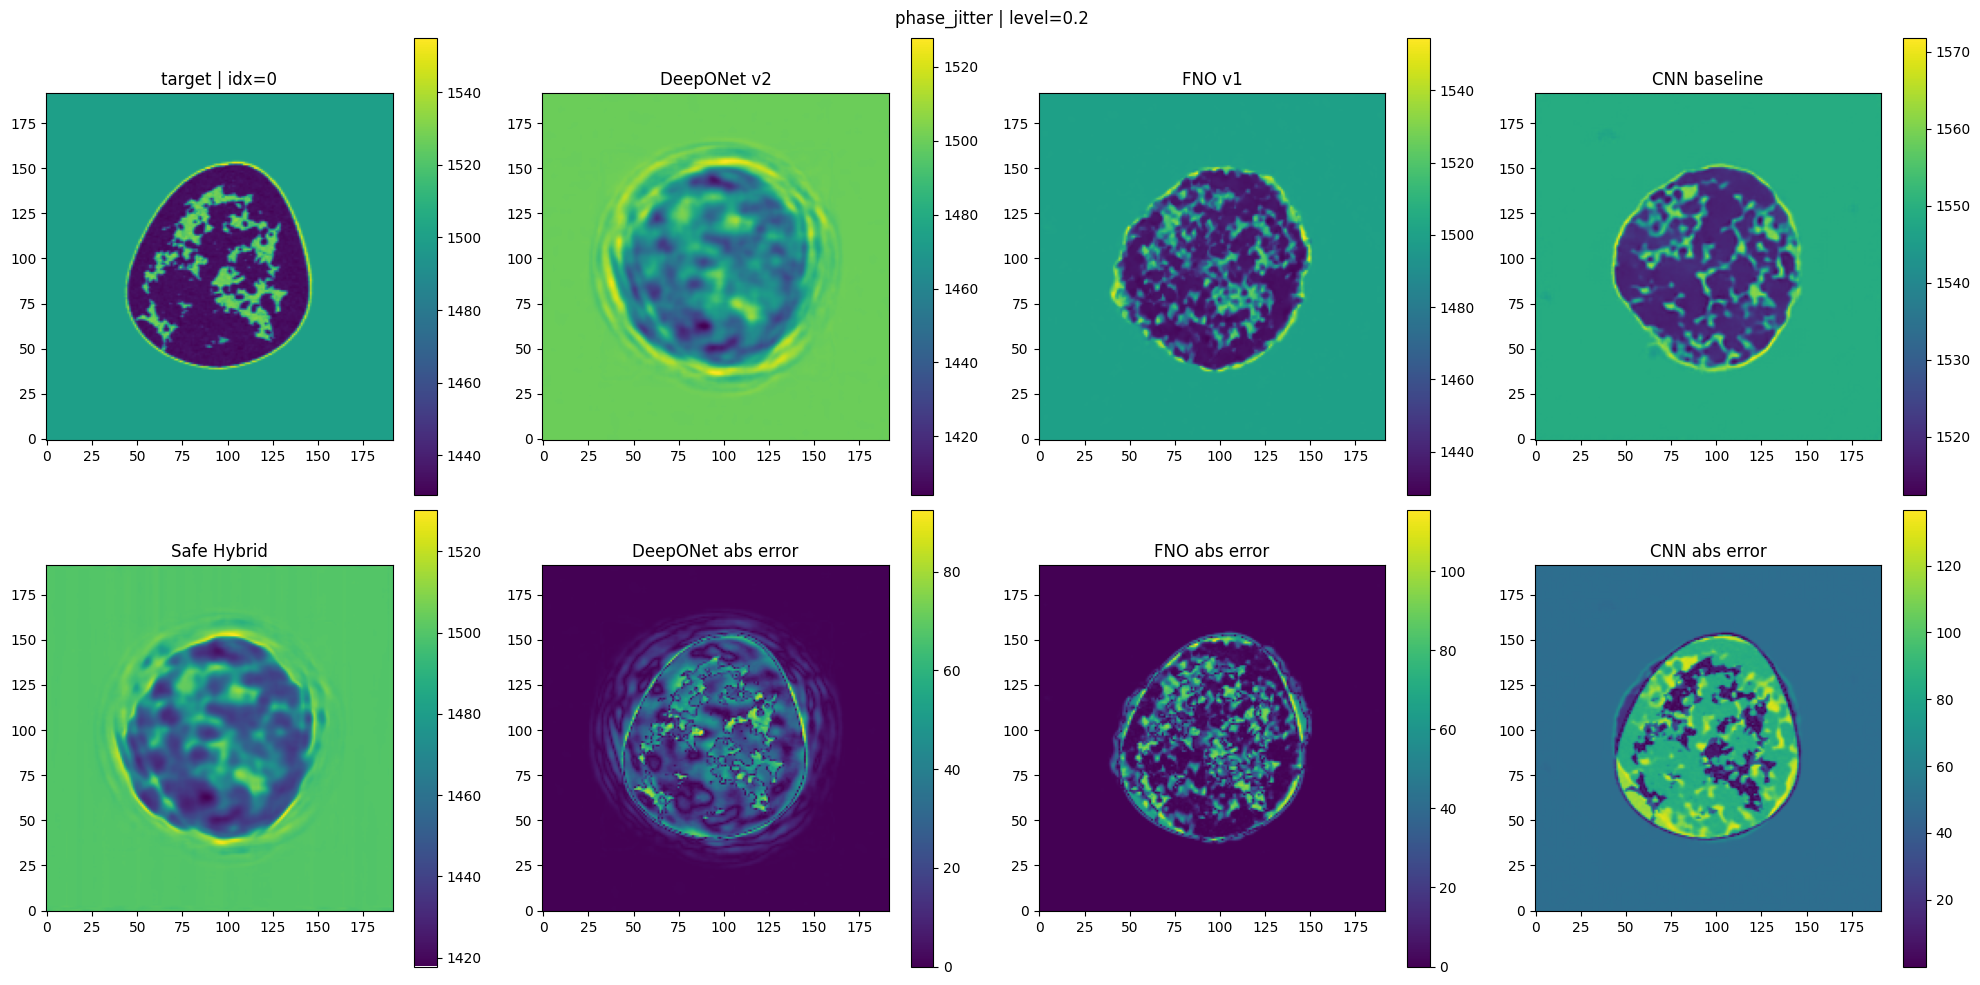

In [22]:
example_idx = int(CFG["vis_example_index"])
x_ex, c_ex, meta_ex = ds_test[example_idx]
x_ex_np = x_ex.numpy()
target = denorm_c_from_minus1_1(c_ex[0].numpy(), stats["c_min"], stats["c_max"])

def show_example_under_noise(perturbation_name, level, title_suffix=""):
    rng = np.random.default_rng(12345)
    x_noisy = apply_perturbation(x_ex_np, perturbation_name, level, rng)

    preds = {}
    for model_name in models.keys():
        pred = predict_model(model_name, x_noisy)
        preds[model_name] = denorm_c_from_minus1_1(pred, stats["c_min"], stats["c_max"])

    has_cnn = "CNN_Baseline" in preds
    fig, ax = plt.subplots(2, 4 if has_cnn else 3, figsize=(20 if has_cnn else 16, 10))

    im0 = ax[0, 0].imshow(target, origin="lower")
    ax[0, 0].set_title(f"target | idx={example_idx}")
    plt.colorbar(im0, ax=ax[0, 0])

    im1 = ax[0, 1].imshow(preds["DeepONet_v2"], origin="lower")
    ax[0, 1].set_title("DeepONet v2")
    plt.colorbar(im1, ax=ax[0, 1])

    im2 = ax[0, 2].imshow(preds["FNO_v1"], origin="lower")
    ax[0, 2].set_title("FNO v1")
    plt.colorbar(im2, ax=ax[0, 2])

    if has_cnn:
        im3 = ax[0, 3].imshow(preds["CNN_Baseline"], origin="lower")
        ax[0, 3].set_title("CNN baseline")
        plt.colorbar(im3, ax=ax[0, 3])

    im4 = ax[1, 0].imshow(preds["Safe_Hybrid"], origin="lower")
    ax[1, 0].set_title("Safe Hybrid")
    plt.colorbar(im4, ax=ax[1, 0])

    im5 = ax[1, 1].imshow(np.abs(preds["DeepONet_v2"] - target), origin="lower")
    ax[1, 1].set_title("DeepONet abs error")
    plt.colorbar(im5, ax=ax[1, 1])

    im6 = ax[1, 2].imshow(np.abs(preds["FNO_v1"] - target), origin="lower")
    ax[1, 2].set_title("FNO abs error")
    plt.colorbar(im6, ax=ax[1, 2])

    if has_cnn:
        im7 = ax[1, 3].imshow(np.abs(preds["CNN_Baseline"] - target), origin="lower")
        ax[1, 3].set_title("CNN abs error")
        plt.colorbar(im7, ax=ax[1, 3])

    plt.suptitle(f"{perturbation_name} | level={level} {title_suffix}")
    plt.tight_layout()
    plt.show()

show_example_under_noise("gaussian", 0.05)
show_example_under_noise("receiver_dropout", 0.20)
show_example_under_noise("phase_jitter", 0.20)


## 10. Save artifacts

In [23]:
RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

df_gaussian.to_csv(RUN_DIR / "gaussian_noise_results.csv", index=False)
df_receiver_dropout.to_csv(RUN_DIR / "receiver_dropout_results.csv", index=False)
df_phase_jitter.to_csv(RUN_DIR / "phase_jitter_results.csv", index=False)
df_all.to_csv(RUN_DIR / "all_noise_robustness_results.csv", index=False)

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "freq_hz": float(freq_hz),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print("saved to:", RUN_DIR)

saved to: /workspace/reference_points/noise_robustness_analysis_v5_with_exact_cnn_loader_fixed
